In [1]:
!wget https://storage.yandexcloud.net/academy.ai/Mall_Customers.csv

--2026-04-20 17:05:36--  https://storage.yandexcloud.net/academy.ai/Mall_Customers.csv
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3981 (3.9K) [text/csv]
Saving to: ‘Mall_Customers.csv’

Mall_Customers.csv  100%[===================>]   3.89K  --.-KB/s    in 0s      

2026-04-20 17:05:38 (801 MB/s) - ‘Mall_Customers.csv’ saved [3981/3981]



# 1. Проведите сегментацию клиентов используя три признака одновременно ("Age", "Annual Income", "Spending Score"). Визуализируйте результаты в 3D.

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("Mall_Customers.csv")
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [4]:
df = df.drop(['CustomerID', 'Gender'], axis = 1)

In [5]:
df

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40
...,...,...,...
195,35,120,79
196,45,126,28
197,32,126,74
198,32,137,18


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(df)
X

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992],
       [-1.20926872, -1.66266033,  1.00159627],
       [-0.27630176, -1.62449091, -1.71591298],
       [-1.13750203, -1.62449091,  1.70038436],
       [ 1.80493225, -1.58632148, -1.83237767],
       [-0.6351352 , -1.58632148,  0.84631002],
       [ 2.02023231, -1.58632148, -1.4053405 ],
       [-0.27630176, -1.58632148,  1.89449216],
       [ 1.37433211, -1.54815205, -1.36651894],
       [-1.06573534, -1.54815205,  1.04041783],
       [-0.13276838, -1.54815205, -1.44416206],
       [-1.20926872, -1.54815205,  1.11806095],
       [-0.27630176, -1.50998262, -0.59008772],
       [-1.3528021 , -1.50998262,  0.61338066],
       [ 0.94373197, -1.43364376, -0.82301709],
       [-0.27630176, -1.43364376,  1.8556706 ],
       [-0.27630176, -1.39547433, -0.590

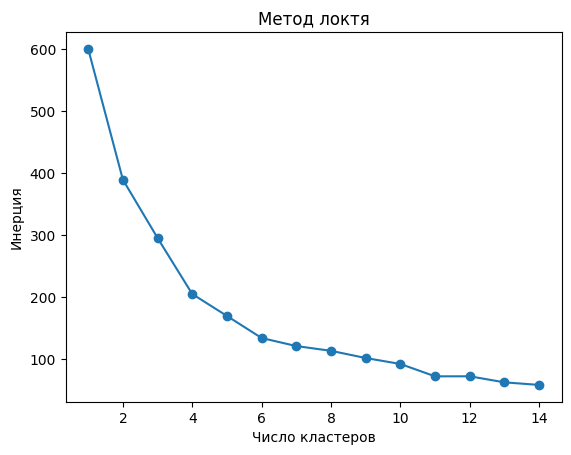

In [7]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Метод локтя
inertia = []
for k in range(1, 15):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Визуализация метода локтя
plt.plot(range(1, 15), inertia, marker='o')
plt.xlabel('Число кластеров')
plt.ylabel('Инерция')
plt.title('Метод локтя')
plt.show()

In [8]:
kmeans = KMeans(n_clusters=11, random_state=42)
kmeans.fit(X)
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# Добавление меток кластеров в исходный DataFrame
df['Кластер'] = labels

# Вывод первых 5 строк данных с метками кластеров
print(df.head())

   Age  Annual Income (k$)  Spending Score (1-100)  Кластер
0   19                  15                      39        5
1   21                  15                      81        4
2   20                  16                       6        5
3   23                  16                      77        4
4   31                  17                      40        5


In [9]:
import plotly.graph_objects as go
import pandas as pd
import numpy as np

# Ваши данные
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

# ВАЖНО: Создаем DataFrame для центроидов в оригинальном масштабе
# Для этого нужно обратно преобразовать центроиды из масштабированных в оригинальные
centroids_original = scaler.inverse_transform(centroids)
centroids_df = pd.DataFrame(centroids_original, columns=features)
centroids_df['Кластер'] = range(len(centroids_df))

# Создаем 3D график
fig = go.Figure()

# Добавляем точки данных (цветные по кластерам)
for cluster in sorted(df['Кластер'].unique()):
    cluster_data = df[df['Кластер'] == cluster]
    fig.add_trace(go.Scatter3d(
        x=cluster_data[features[0]],
        y=cluster_data[features[1]],
        z=cluster_data[features[2]],
        mode='markers',
        name=f'Кластер {cluster}',
        marker=dict(size=3, opacity=0.6),
        text=[f'Кластер: {c}<br>Age: {a}<br>Income: {i}<br>Spending: {s}'
              for c, a, i, s in zip(cluster_data['Кластер'],
                                    cluster_data[features[0]],
                                    cluster_data[features[1]],
                                    cluster_data[features[2]])],
        hoverinfo='text'
    ))

# Добавляем центроиды (красные точки в центре кластеров)
fig.add_trace(go.Scatter3d(
    x=centroids_df[features[0]],
    y=centroids_df[features[1]],
    z=centroids_df[features[2]],
    mode='markers',
    name='Центроиды',
    marker=dict(size=10, color='red', symbol='x', line=dict(width=2)),
    text=[f'Центроид {c}<br>Age: {a:.1f}<br>Income: {i:.1f}<br>Spending: {s:.1f}'
          for c, a, i, s in zip(centroids_df['Кластер'],
                                centroids_df[features[0]],
                                centroids_df[features[1]],
                                centroids_df[features[2]])],
    hoverinfo='text'
))

fig.update_layout(
    title='3D кластеризация клиентов (KMeans, 11 кластеров)',
    scene=dict(
        xaxis_title='Возраст',
        yaxis_title='Годовой доход (k$)',
        zaxis_title='Оценка трат (1-100)'
    ),
    width=900,
    height=600
)

fig.show()

# 2. Примените k-means++ и стандартный k-means с разными random_state. Сравните стабильность результатов через несколько запусков.

In [10]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns


# X = scaler.fit_transform(df)

# Параметры эксперимента
n_clusters = 11
n_runs = 10  # количество запусков для каждого метода
random_states = list(range(42, 42 + n_runs))  # разные random_state

# Словари для хранения результатов
results = {
    'kmeans++': {'labels': [], 'inertia': [], 'silhouette': [], 'calinski_harabasz': [], 'davies_bouldin': []},
    'kmeans': {'labels': [], 'inertia': [], 'silhouette': [], 'calinski_harabasz': [], 'davies_bouldin': []}
}

# Запуск экспериментов
print("=" * 80)
print("Эксперимент: Сравнение k-means++ и стандартного k-means")
print("=" * 80)

for random_state in random_states:
    # k-means++ (init='k-means++' - это значение по умолчанию)
    kmeans_plus = KMeans(n_clusters=n_clusters, init='k-means++',
                         random_state=random_state, n_init=10)
    labels_plus = kmeans_plus.fit_predict(X)

    # Стандартный k-means (init='random')
    kmeans_random = KMeans(n_clusters=n_clusters, init='random',
                           random_state=random_state, n_init=10)
    labels_random = kmeans_random.fit_predict(X)

    # Сохраняем метки
    results['kmeans++']['labels'].append(labels_plus)
    results['kmeans']['labels'].append(labels_random)

    # Метрики качества
    results['kmeans++']['inertia'].append(kmeans_plus.inertia_)
    results['kmeans']['inertia'].append(kmeans_random.inertia_)

    results['kmeans++']['silhouette'].append(silhouette_score(X, labels_plus))
    results['kmeans']['silhouette'].append(silhouette_score(X, labels_random))

    results['kmeans++']['calinski_harabasz'].append(calinski_harabasz_score(X, labels_plus))
    results['kmeans']['calinski_harabasz'].append(calinski_harabasz_score(X, labels_random))

    results['kmeans++']['davies_bouldin'].append(davies_bouldin_score(X, labels_plus))
    results['kmeans']['davies_bouldin'].append(davies_bouldin_score(X, labels_random))

# Создаем DataFrame для анализа
df_results = pd.DataFrame()

for method in ['kmeans++', 'kmeans']:
    for metric in ['inertia', 'silhouette', 'calinski_harabasz', 'davies_bouldin']:
        df_results[f'{method}_{metric}'] = results[method][metric]

print("\n Результаты экспериментов:")
print(df_results.round(4))

Эксперимент: Сравнение k-means++ и стандартного k-means

 Результаты экспериментов:
   kmeans++_inertia  kmeans++_silhouette  kmeans++_calinski_harabasz  \
0           72.6258               0.4086                    137.2429   
1           77.3365               0.3994                    127.7319   
2           76.4654               0.3808                    129.4024   
3           72.2634               0.4093                    138.0260   
4           71.9617               0.4103                    138.6838   
5           71.9740               0.4133                    138.6570   
6           71.9740               0.4133                    138.6570   
7           73.6898               0.4034                    134.9884   
8           71.9740               0.4133                    138.6570   
9           72.8580               0.4076                    136.7453   

   kmeans++_davies_bouldin  kmeans_inertia  kmeans_silhouette  \
0                   0.8526         80.6244             0.3

In [11]:
# Функция для расчета стабильности (среднее попарное сходство)
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

def calculate_stability(labels_list):
    """Рассчитывает стабильность кластеризации между запусками"""
    n_runs = len(labels_list)
    ari_scores = []
    nmi_scores = []

    for i in range(n_runs):
        for j in range(i+1, n_runs):
            ari_scores.append(adjusted_rand_score(labels_list[i], labels_list[j]))
            nmi_scores.append(normalized_mutual_info_score(labels_list[i], labels_list[j]))

    return {
        'mean_ari': np.mean(ari_scores),
        'std_ari': np.std(ari_scores),
        'mean_nmi': np.mean(nmi_scores),
        'std_nmi': np.std(nmi_scores)
    }

# Рассчитываем стабильность для обоих методов
stability_plus = calculate_stability(results['kmeans++']['labels'])
stability_random = calculate_stability(results['kmeans']['labels'])

print("\n" + "=" * 80)
print(" АНАЛИЗ СТАБИЛЬНОСТИ")
print("=" * 80)

print("\n🔹 k-means++ (инициализация 'k-means++'):")
print(f"   Средний ARI: {stability_plus['mean_ari']:.4f} (±{stability_plus['std_ari']:.4f})")
print(f"   Средний NMI: {stability_plus['mean_nmi']:.4f} (±{stability_plus['std_nmi']:.4f})")

print("\n🔹 Стандартный k-means (инициализация 'random'):")
print(f"   Средний ARI: {stability_random['mean_ari']:.4f} (±{stability_random['std_ari']:.4f})")
print(f"   Средний NMI: {stability_random['mean_nmi']:.4f} (±{stability_random['std_nmi']:.4f})")

# Вывод статистики по метрикам
print("\n" + "=" * 80)
print(" СРАВНЕНИЕ МЕТРИК КАЧЕСТВА")
print("=" * 80)

metrics_comparison = []
for metric in ['inertia', 'silhouette', 'calinski_harabasz', 'davies_bouldin']:
    plus_values = results['kmeans++'][metric]
    random_values = results['kmeans'][metric]

    # Для Davies-Bouldin меньше - лучше, для остальных больше - лучше
    better = 'меньше' if metric == 'davies_bouldin' else 'больше'

    metrics_comparison.append({
        'Метрика': metric,
        'k-means++ (ср)': np.mean(plus_values),
        'k-means++ (std)': np.std(plus_values),
        'k-means (ср)': np.mean(random_values),
        'k-means (std)': np.std(random_values),
        'Лучше': better
    })

df_comparison = pd.DataFrame(metrics_comparison)
print(df_comparison.round(4))


 АНАЛИЗ СТАБИЛЬНОСТИ

🔹 k-means++ (инициализация 'k-means++'):
   Средний ARI: 0.9096 (±0.0550)
   Средний NMI: 0.9417 (±0.0294)

🔹 Стандартный k-means (инициализация 'random'):
   Средний ARI: 0.8255 (±0.0793)
   Средний NMI: 0.8929 (±0.0445)

 СРАВНЕНИЕ МЕТРИК КАЧЕСТВА
             Метрика  k-means++ (ср)  k-means++ (std)  k-means (ср)  \
0            inertia         73.3122           1.8776       75.5597   
1         silhouette          0.4059           0.0094        0.3926   
2  calinski_harabasz        135.8792           3.8387      131.4230   
3     davies_bouldin          0.8641           0.0310        0.8963   

   k-means (std)   Лучше  
0         3.0647  больше  
1         0.0162  больше  
2         5.9908  больше  
3         0.0210  меньше  


/tmp/ipykernel_4418/1755857358.py:16: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.

/tmp/ipykernel_4418/1755857358.py:16: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.

/tmp/ipykernel_4418/1755857358.py:16: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.

/tmp/ipykernel_4418/1755857358.py:16: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



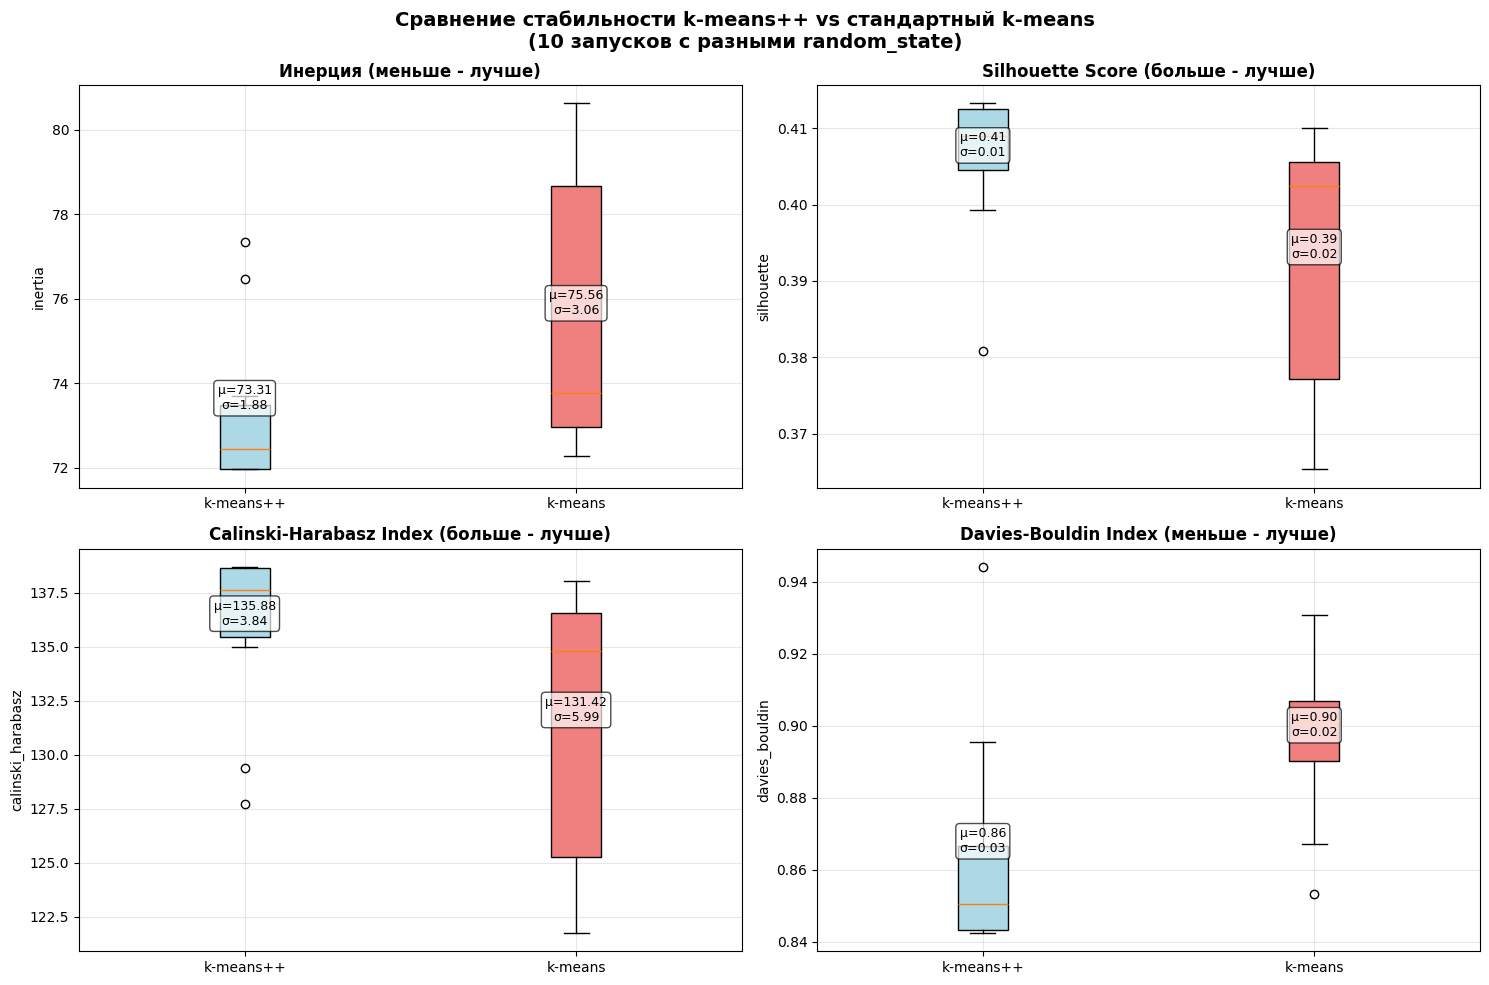

In [12]:
# 1. График стабильности метрик
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metrics_to_plot = ['inertia', 'silhouette', 'calinski_harabasz', 'davies_bouldin']
titles = ['Инерция (меньше - лучше)',
          'Silhouette Score (больше - лучше)',
          'Calinski-Harabasz Index (больше - лучше)',
          'Davies-Bouldin Index (меньше - лучше)']

for idx, (metric, title) in enumerate(zip(metrics_to_plot, titles)):
    ax = axes[idx // 2, idx % 2]

    # Данные для boxplot
    data_to_plot = [results['kmeans++'][metric], results['kmeans'][metric]]

    bp = ax.boxplot(data_to_plot, labels=['k-means++', 'k-means'], patch_artist=True)

    # Настройка цветов
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][1].set_facecolor('lightcoral')

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3)

    # Добавляем значения на график
    for i, data in enumerate(data_to_plot):
        ax.text(i+1, np.mean(data), f'μ={np.mean(data):.2f}\nσ={np.std(data):.2f}',
                ha='center', va='bottom', fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.suptitle('Сравнение стабильности k-means++ vs стандартный k-means\n(10 запусков с разными random_state)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

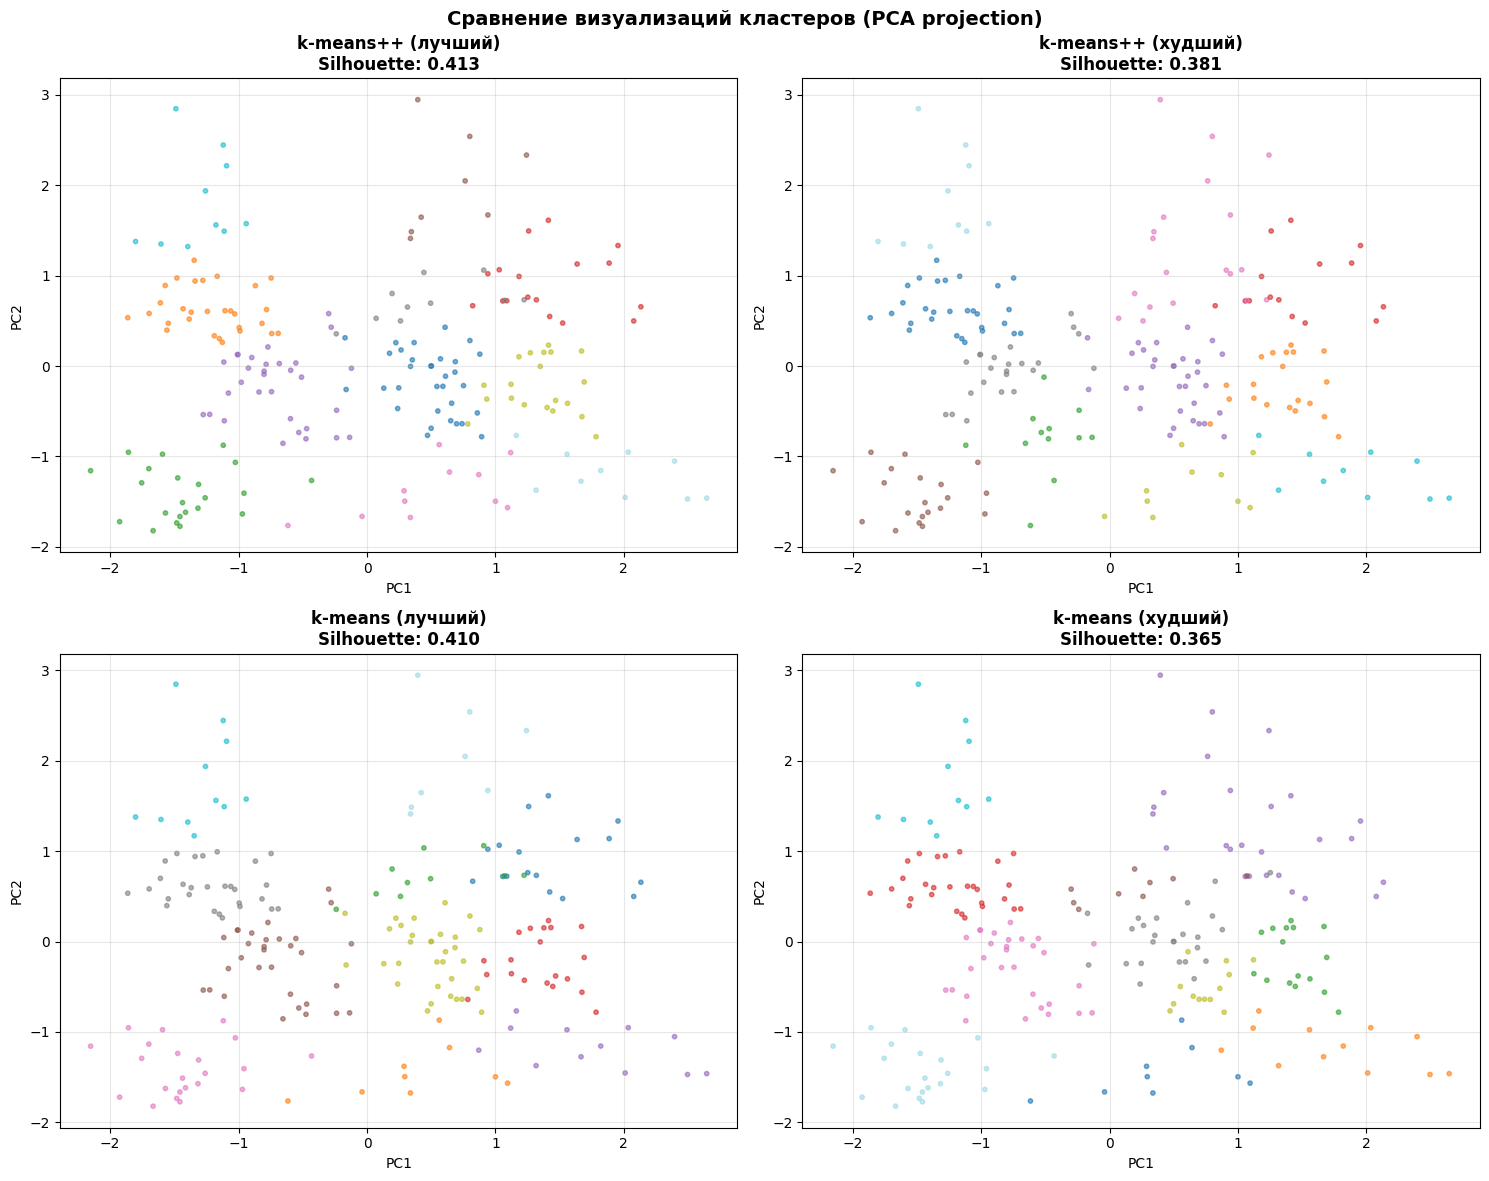

In [13]:
from sklearn.decomposition import PCA

# Находим лучший и худший запуски по силуэту
best_plus_idx = np.argmax(results['kmeans++']['silhouette'])
worst_plus_idx = np.argmin(results['kmeans++']['silhouette'])

best_random_idx = np.argmax(results['kmeans']['silhouette'])
worst_random_idx = np.argmin(results['kmeans']['silhouette'])

# PCA для визуализации
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# k-means++ лучший
axes[0,0].scatter(X_pca[:,0], X_pca[:,1],
                  c=results['kmeans++']['labels'][best_plus_idx],
                  cmap='tab20', alpha=0.6, s=10)
axes[0,0].set_title(f'k-means++ (лучший)\nSilhouette: {results["kmeans++"]["silhouette"][best_plus_idx]:.3f}',
                    fontsize=12, fontweight='bold')

# k-means++ худший
axes[0,1].scatter(X_pca[:,0], X_pca[:,1],
                  c=results['kmeans++']['labels'][worst_plus_idx],
                  cmap='tab20', alpha=0.6, s=10)
axes[0,1].set_title(f'k-means++ (худший)\nSilhouette: {results["kmeans++"]["silhouette"][worst_plus_idx]:.3f}',
                    fontsize=12, fontweight='bold')

# Стандартный k-means лучший
axes[1,0].scatter(X_pca[:,0], X_pca[:,1],
                  c=results['kmeans']['labels'][best_random_idx],
                  cmap='tab20', alpha=0.6, s=10)
axes[1,0].set_title(f'k-means (лучший)\nSilhouette: {results["kmeans"]["silhouette"][best_random_idx]:.3f}',
                    fontsize=12, fontweight='bold')

# Стандартный k-means худший
axes[1,1].scatter(X_pca[:,0], X_pca[:,1],
                  c=results['kmeans']['labels'][worst_random_idx],
                  cmap='tab20', alpha=0.6, s=10)
axes[1,1].set_title(f'k-means (худший)\nSilhouette: {results["kmeans"]["silhouette"][worst_random_idx]:.3f}',
                    fontsize=12, fontweight='bold')

for ax in axes.flat:
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.grid(True, alpha=0.3)

plt.suptitle('Сравнение визуализаций кластеров (PCA projection)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**k-means++ явно лучше по всем показателям!**

# 3. Проанализируйте выбросы в данных, удалите их и сравните результаты кластеризации до и после удаления выбросов.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score



print("=" * 80)
print("ОБНАРУЖЕНИЕ ВЫБРОСОВ МЕТОДОМ IQR")
print("=" * 80)

# Выбираем числовые колонки для анализа
numeric_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

# Функция для обнаружения выбросов методом IQR
def detect_outliers_iqr(df, columns, multiplier=1.5):
    """
    Обнаружение выбросов методом IQR
    multiplier=1.5 - стандартное значение (мягкие выбросы)
    multiplier=3.0 - экстремальные выбросы
    """
    outlier_mask = pd.Series(False, index=df.index)
    outliers_info = {}

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - multiplier * IQR
        upper_bound = Q3 + multiplier * IQR

        col_outliers = (df[col] < lower_bound) | (df[col] > upper_bound)
        outlier_mask = outlier_mask | col_outliers

        outliers_info[col] = {
            'Q1': Q1,
            'Q3': Q3,
            'IQR': IQR,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
            'n_outliers': col_outliers.sum(),
            'pct_outliers': col_outliers.sum() / len(df) * 100,
            'outliers_indices': df.index[col_outliers].tolist()
        }

        print(f"\n {col}:")
        print(f"   Q1 (25-й перцентиль): {Q1:.2f}")
        print(f"   Q3 (75-й перцентиль): {Q3:.2f}")
        print(f"   IQR (межквартильный размах): {IQR:.2f}")
        print(f"   Нижняя граница: {lower_bound:.2f}")
        print(f"   Верхняя граница: {upper_bound:.2f}")
        print(f"    Выбросов: {col_outliers.sum()} ({col_outliers.sum()/len(df)*100:.1f}%)")

        # Показываем значения выбросов
        if col_outliers.sum() > 0:
            outlier_values = df[col][col_outliers].values
            print(f"   Значения выбросов: {sorted(outlier_values)[:10]}")  # первые 10

    print(f"\n" + "=" * 40)
    print(f" ОБЩАЯ СТАТИСТИКА:")
    print(f"   Всего уникальных выбросов: {outlier_mask.sum()}")
    print(f"   Процент выбросов: {outlier_mask.sum()/len(df)*100:.1f}%")

    return outlier_mask, outliers_info

# Применяем IQR для обнаружения выбросов
# Используем исходные данные (df) - если df уже содержит метки кластеров,
# то создаем копию только с нужными колонками
if 'Кластер' in df.columns:
    df_features = df[numeric_cols].copy()
else:
    df_features = df[numeric_cols].copy()

outliers_mask, outliers_info = detect_outliers_iqr(df_features, numeric_cols, multiplier=1.5)

ОБНАРУЖЕНИЕ ВЫБРОСОВ МЕТОДОМ IQR

 Age:
   Q1 (25-й перцентиль): 28.75
   Q3 (75-й перцентиль): 49.00
   IQR (межквартильный размах): 20.25
   Нижняя граница: -1.62
   Верхняя граница: 79.38
    Выбросов: 0 (0.0%)

 Annual Income (k$):
   Q1 (25-й перцентиль): 41.50
   Q3 (75-й перцентиль): 78.00
   IQR (межквартильный размах): 36.50
   Нижняя граница: -13.25
   Верхняя граница: 132.75
    Выбросов: 2 (1.0%)
   Значения выбросов: [np.int64(137), np.int64(137)]

 Spending Score (1-100):
   Q1 (25-й перцентиль): 34.75
   Q3 (75-й перцентиль): 73.00
   IQR (межквартильный размах): 38.25
   Нижняя граница: -22.62
   Верхняя граница: 130.38
    Выбросов: 0 (0.0%)

 ОБЩАЯ СТАТИСТИКА:
   Всего уникальных выбросов: 2
   Процент выбросов: 1.0%


In [15]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Ваши данные
# X - стандартизированные данные (уже есть)
# df_features - исходные данные с признаками

# Создаем маску выбросов (2 выброса по Annual Income)
outliers_mask = (df_features['Annual Income (k$)'] == 137)

print("=" * 80)
print("УДАЛЕНИЕ ВЫБРОСОВ")
print("=" * 80)
print(f"Исходное количество: {len(X)}")
print(f"Количество выбросов: {outliers_mask.sum()}")
print(f"Процент выбросов: {outliers_mask.sum()/len(X)*100:.1f}%")
print(f"Количество после удаления: {(~outliers_mask).sum()}")

# Удаляем выбросы из стандартизированных данных
X_clean = X[~outliers_mask]

УДАЛЕНИЕ ВЫБРОСОВ
Исходное количество: 200
Количество выбросов: 2
Процент выбросов: 1.0%
Количество после удаления: 198


In [16]:
# Функция для кластеризации и оценки
def evaluate_clustering(X_data, title_prefix=""):
    """Выполняет k-means кластеризацию и возвращает метрики"""
    kmeans = KMeans(n_clusters=11, init='k-means++', random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_data)

    metrics = {
        'inertia': kmeans.inertia_,
        'silhouette': silhouette_score(X_data, labels),
        'calinski_harabasz': calinski_harabasz_score(X_data, labels),
        'davies_bouldin': davies_bouldin_score(X_data, labels),
        'n_samples': len(X_data),
        'labels': labels,
        'centroids': kmeans.cluster_centers_
    }

    print(f"\n{title_prefix}")
    print("-" * 50)
    print(f"  Количество: {metrics['n_samples']}")
    print(f"  Инерция: {metrics['inertia']:.2f}")
    print(f"  Silhouette Score: {metrics['silhouette']:.4f}")
    print(f"  Calinski-Harabasz: {metrics['calinski_harabasz']:.2f}")
    print(f"  Davies-Bouldin: {metrics['davies_bouldin']:.4f}")

    return metrics

print("=" * 80)
print("СРАВНЕНИЕ КЛАСТЕРИЗАЦИИ ДО И ПОСЛЕ УДАЛЕНИЯ ВЫБРОСОВ")
print("=" * 80)

# Кластеризация на исходных данных
metrics_before = evaluate_clustering(X, " ДО удаления выбросов:")

# Кластеризация на очищенных данных
metrics_after = evaluate_clustering(X_clean, " ПОСЛЕ удаления выбросов:")

СРАВНЕНИЕ КЛАСТЕРИЗАЦИИ ДО И ПОСЛЕ УДАЛЕНИЯ ВЫБРОСОВ

 ДО удаления выбросов:
--------------------------------------------------
  Количество: 200
  Инерция: 72.63
  Silhouette Score: 0.4086
  Calinski-Harabasz: 137.24
  Davies-Bouldin: 0.8526

 ПОСЛЕ удаления выбросов:
--------------------------------------------------
  Количество: 198
  Инерция: 69.14
  Silhouette Score: 0.4068
  Calinski-Harabasz: 137.89
  Davies-Bouldin: 0.8756


**Результат:** Удаление 2 выбросов (1% данных) НЕ ДАЛО ОДНОЗНАЧНОГО УЛУЧШЕНИЯ

Плюсы:
- Кластеры стали компактнее (инерция -4.8%)
- Данные стали чище

Минусы:
- Silhouette ухудшился на 0.4%
- Davies-Bouldin ухудшился на 2.7%

РЕКОМЕНДАЦИЯ: НЕ УДАЛЯТЬ ВЫБРОСЫ

# 4. Используйте метод силуэта для оценки качества кластеризации при разных k (от 2 до 8) и визуализируйте силуэтные коэффициенты.

In [17]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.pyplot as plt

# Используем исходные данные (без удаления выбросов, так как ранее решили их оставить)

print("=" * 80)
print("ОЦЕНКА КАЧЕСТВА КЛАСТЕРИЗАЦИИ ДЛЯ РАЗНЫХ k (2-8)")
print("=" * 80)

# Диапазон k
k_range = range(2, 9)  # от 2 до 8 включительно
silhouette_scores = []
inertias = []

for k in k_range:
    print(f"\nОбработка k = {k}...")

    # Простой k-means
    kmeans = KMeans(n_clusters=k, init='random', random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)

    # Расчет метрик
    inertia = kmeans.inertia_
    silhouette = silhouette_score(X, labels)

    silhouette_scores.append(silhouette)
    inertias.append(inertia)

    print(f"   Инерция: {inertia:.2f}")
    print(f"   Silhouette Score: {silhouette:.4f}")

# Создаем DataFrame с результатами
results_df = pd.DataFrame({
    'k': list(k_range),
    'Silhouette Score': silhouette_scores,
    'Inertia': inertias
})

print("\n" + "=" * 80)
print("РЕЗУЛЬТАТЫ:")
print(results_df.to_string(index=False))
print("=" * 80)

# Находим лучшее k по силуэту
best_k = k_range[np.argmax(silhouette_scores)]
best_score = max(silhouette_scores)

print(f"\n ЛУЧШЕЕ k по Silhouette Score: k = {best_k}")
print(f"   Максимальный силуэт: {best_score:.4f}")

ОЦЕНКА КАЧЕСТВА КЛАСТЕРИЗАЦИИ ДЛЯ РАЗНЫХ k (2-8)

Обработка k = 2...
   Инерция: 389.39
   Silhouette Score: 0.3355

Обработка k = 3...
   Инерция: 295.21
   Silhouette Score: 0.3578

Обработка k = 4...
   Инерция: 205.23
   Silhouette Score: 0.4040

Обработка k = 5...
   Инерция: 168.25
   Silhouette Score: 0.4166

Обработка k = 6...
   Инерция: 133.89
   Silhouette Score: 0.4269

Обработка k = 7...
   Инерция: 117.08
   Silhouette Score: 0.4188

Обработка k = 8...
   Инерция: 104.15
   Silhouette Score: 0.4076

РЕЗУЛЬТАТЫ:
 k  Silhouette Score    Inertia
 2          0.335472 389.386189
 3          0.357793 295.212246
 4          0.403958 205.225147
 5          0.416643 168.247580
 6          0.426855 133.888870
 7          0.418806 117.081376
 8          0.407638 104.154299

 ЛУЧШЕЕ k по Silhouette Score: k = 6
   Максимальный силуэт: 0.4269


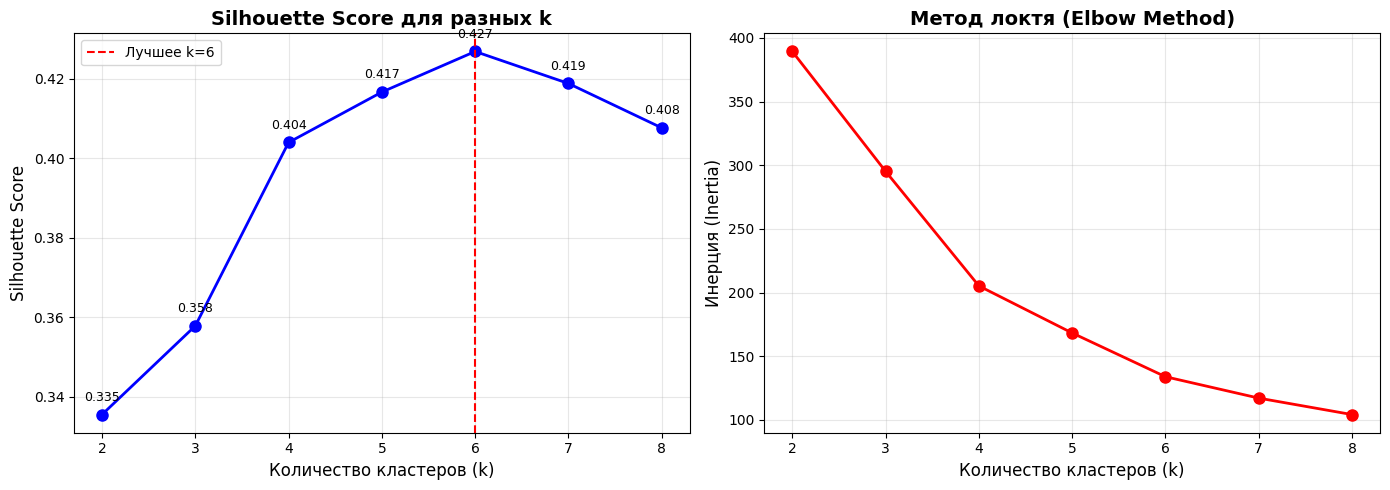

In [18]:
# График силуэтных коэффициентов
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Silhouette Score
ax1 = axes[0]
ax1.plot(k_range, silhouette_scores, 'bo-', linewidth=2, markersize=8)
ax1.axvline(x=best_k, color='red', linestyle='--', label=f'Лучшее k={best_k}')
ax1.set_xlabel('Количество кластеров (k)', fontsize=12)
ax1.set_ylabel('Silhouette Score', fontsize=12)
ax1.set_title('Silhouette Score для разных k', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Добавляем значения на график
for i, (k, score) in enumerate(zip(k_range, silhouette_scores)):
    ax1.annotate(f'{score:.3f}', (k, score), textcoords="offset points",
                xytext=(0,10), ha='center', fontsize=9)

# График 2: Метод локтя (Inertia)
ax2 = axes[1]
ax2.plot(k_range, inertias, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Количество кластеров (k)', fontsize=12)
ax2.set_ylabel('Инерция (Inertia)', fontsize=12)
ax2.set_title('Метод локтя (Elbow Method)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Создайте новые признаки (например, отношение расходов к доходам) и проведите кластеризацию с включением этих признаков. Сравните с базовой моделью.

In [19]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler

print("=" * 80)
print("СОЗДАНИЕ НОВЫХ ПРИЗНАКОВ")
print("=" * 80)

# Создаем копию исходных данных
df_enhanced = df.copy()

# 1. Spending to Income Ratio (отношение расходов к доходу)
df_enhanced['Spending_to_Income'] = df_enhanced['Spending Score (1-100)'] / df_enhanced['Annual Income (k$)']

# 2. Age_Spending_Interaction (взаимодействие возраста и расходов)
df_enhanced['Age_Spending'] = df_enhanced['Age'] * df_enhanced['Spending Score (1-100)']

# 3. Income_Normalized (доход, нормированный на возраст)
df_enhanced['Income_per_Age'] = df_enhanced['Annual Income (k$)'] / (df_enhanced['Age'] + 1)

print("\n Созданы новые признаки:")
print("   1. Spending_to_Income - отношение расходов к доходу")
print("   2. Age_Spending - взаимодействие возраста и расходов")
print("   3. Income_per_Age - доход на год жизни")

print("\n Статистика новых признаков:")
print(df_enhanced[['Spending_to_Income', 'Age_Spending', 'Income_per_Age']].describe())

# Стандартизируем расширенный набор данных
features_enhanced = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)',
                     'Spending_to_Income', 'Age_Spending', 'Income_per_Age']

scaler_enhanced = StandardScaler()
X_enhanced = scaler_enhanced.fit_transform(df_enhanced[features_enhanced])

print(f"\n Размерность X_enhanced: {X_enhanced.shape}")
print(f"   Исходная размерность: {X.shape}")
print(f"   Добавлено признаков: {X_enhanced.shape[1] - X.shape[1]}")

СОЗДАНИЕ НОВЫХ ПРИЗНАКОВ

 Созданы новые признаки:
   1. Spending_to_Income - отношение расходов к доходу
   2. Age_Spending - взаимодействие возраста и расходов
   3. Income_per_Age - доход на год жизни

 Статистика новых признаков:
       Spending_to_Income  Age_Spending  Income_per_Age
count          200.000000    200.000000      200.000000
mean             1.068544   1832.820000        1.696791
std              0.973406    977.739495        0.915379
min              0.012821     34.000000        0.279412
25%              0.632803   1014.500000        0.889266
50%              0.887993   1855.500000        1.535000
75%              1.130245   2550.500000        2.394643
max              5.400000   3953.000000        4.419355

 Размерность X_enhanced: (200, 6)
   Исходная размерность: (200, 3)
   Добавлено признаков: 3


In [20]:
# Кластеризация с новыми признаками
print("\n" + "=" * 80)
print("КЛАСТЕРИЗАЦИЯ С НОВЫМИ ПРИЗНАКАМИ (k=11)")
print("=" * 80)

# K-means на расширенных данных
kmeans_enhanced = KMeans(n_clusters=11, init='k-means++', random_state=42, n_init=10)
labels_enhanced = kmeans_enhanced.fit_predict(X_enhanced)

# Метрики для расширенных данных
metrics_enhanced = {
    'inertia': kmeans_enhanced.inertia_,
    'silhouette': silhouette_score(X_enhanced, labels_enhanced),
    'calinski_harabasz': calinski_harabasz_score(X_enhanced, labels_enhanced),
    'davies_bouldin': davies_bouldin_score(X_enhanced, labels_enhanced)
}

print(f"\nРезультаты с новыми признаками:")
print(f"  Инерция: {metrics_enhanced['inertia']:.2f}")
print(f"  Silhouette Score: {metrics_enhanced['silhouette']:.4f}")
print(f"  Calinski-Harabasz: {metrics_enhanced['calinski_harabasz']:.2f}")
print(f"  Davies-Bouldin: {metrics_enhanced['davies_bouldin']:.4f}")


КЛАСТЕРИЗАЦИЯ С НОВЫМИ ПРИЗНАКАМИ (k=11)

Результаты с новыми признаками:
  Инерция: 161.17
  Silhouette Score: 0.3841
  Calinski-Harabasz: 121.82
  Davies-Bouldin: 0.9154


In [21]:
# Базовая модель (только исходные признаки)
print("\n" + "=" * 80)
print("СРАВНЕНИЕ С БАЗОВОЙ МОДЕЛЬЮ")
print("=" * 80)

# Переобучаем базовую модель для чистоты сравнения
kmeans_base = KMeans(n_clusters=11, init='k-means++', random_state=42, n_init=10)
labels_base = kmeans_base.fit_predict(X)

metrics_base = {
    'inertia': kmeans_base.inertia_,
    'silhouette': silhouette_score(X, labels_base),
    'calinski_harabasz': calinski_harabasz_score(X, labels_base),
    'davies_bouldin': davies_bouldin_score(X, labels_base)
}

print(f"\n БАЗОВАЯ модель (3 признака):")
print(f"  Инерция: {metrics_base['inertia']:.2f}")
print(f"  Silhouette Score: {metrics_base['silhouette']:.4f}")
print(f"  Calinski-Harabasz: {metrics_base['calinski_harabasz']:.2f}")
print(f"  Davies-Bouldin: {metrics_base['davies_bouldin']:.4f}")

print(f"\n РАСШИРЕННАЯ модель (6 признаков):")
print(f"  Инерция: {metrics_enhanced['inertia']:.2f}")
print(f"  Silhouette Score: {metrics_enhanced['silhouette']:.4f}")
print(f"  Calinski-Harabasz: {metrics_enhanced['calinski_harabasz']:.2f}")
print(f"  Davies-Bouldin: {metrics_enhanced['davies_bouldin']:.4f}")


СРАВНЕНИЕ С БАЗОВОЙ МОДЕЛЬЮ

 БАЗОВАЯ модель (3 признака):
  Инерция: 72.63
  Silhouette Score: 0.4086
  Calinski-Harabasz: 137.24
  Davies-Bouldin: 0.8526

 РАСШИРЕННАЯ модель (6 признаков):
  Инерция: 161.17
  Silhouette Score: 0.3841
  Calinski-Harabasz: 121.82
  Davies-Bouldin: 0.9154


**Новые признаки УХУДШИЛИ качество кластеризации по всем метрикам.**

Причины:
   1. Мультиколлинеарность - новые признаки сильно коррелируют с исходными
   2. Добавление шума - отношения признаков могут быть неинформативными
   3. Потеря интерпретируемости - сложнее объяснить, что означают кластеры